In [1]:
from pathlib import Path
import geopandas as gpd
import pandas as pd

# SMART-DS grid geometry: all of this location's 2016 base-timeseries feeders.
location_name = Path("..").resolve().name
root = Path("../data/smart_ds/2016")
paths = sorted(root.glob("*/scenarios/base_timeseries/geojson/*.json"))
grid = pd.concat([gpd.read_file(path).assign(subregion=path.parts[-5], feeder=path.stem) for path in paths], ignore_index=True)
ax = grid[grid["type"].eq("Line")].plot(figsize=(9, 9), linewidth=0.25, color="tab:blue", alpha=0.55)
grid[~grid["type"].eq("Line")].plot(ax=ax, markersize=0.15, color="black", alpha=0.25)
ax.set_title(f"SMART-DS {location_name.title()} base grid ({len(paths)} feeders)")
ax.set_axis_off()

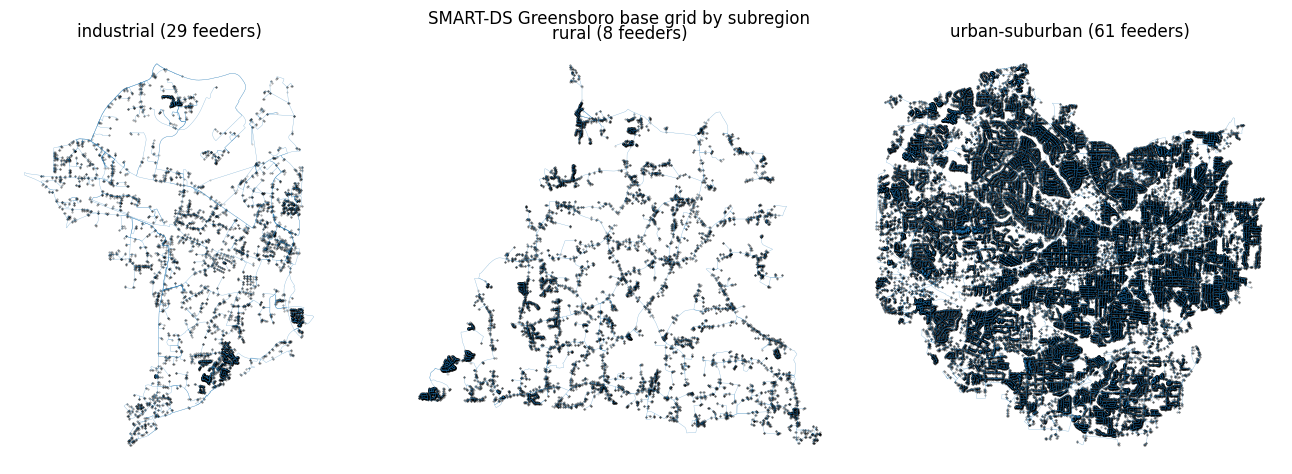

In [2]:
import math
import matplotlib.pyplot as plt

def plot_smartds_subregions(grid, *, ncols=3, line_width=0.25, node_size=0.15):
    subregions = sorted(grid["subregion"].dropna().unique())
    nrows = math.ceil(len(subregions) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows), constrained_layout=True)
    axes = list(axes.ravel())

    for ax, subregion in zip(axes, subregions):
        subset = grid[grid["subregion"].eq(subregion)]
        lines = subset[subset["type"].eq("Line")]
        points = subset[~subset["type"].eq("Line")]
        lines.plot(ax=ax, linewidth=line_width, color="tab:blue", alpha=0.55)
        points.plot(ax=ax, markersize=node_size, color="black", alpha=0.25)
        ax.set_title(f"{subregion} ({subset['feeder'].nunique()} feeders)")
        ax.set_axis_off()

    for ax in axes[len(subregions):]:
        ax.set_axis_off()

    fig.suptitle(f"SMART-DS {location_name.title()} base grid by subregion", y=1.02)
    return fig, axes[:len(subregions)]

fig, axes = plot_smartds_subregions(grid)

In [ ]:
import math
import pydeck as pdk
from IPython.display import HTML, display

selected_subregion = "rural"  # Choose after reviewing the subregion plot above; None shows all subregions.

def deck_legend(title, items):
    rows = "".join(
        f"<span style='display:inline-flex;align-items:center;margin-right:16px;'>"
        f"<span style='display:inline-block;width:12px;height:12px;background:{color};margin-right:6px;border:1px solid #555;'></span>"
        f"{label}</span>"
        for label, color in items
    )
    return HTML(f"<div style='font-family:sans-serif;margin:4px 0 8px 0;'><b>{title}</b><br>{rows}<span style='color:#555;'>Hover features for subregion, feeder, and asset type.</span></div>")

def plot_smartds_deck(grid, *, subregion=None, height=720, simplify_tolerance=0.00001):
    web_grid = grid[["subregion", "feeder", "type", "geometry"]].copy()
    if subregion is not None:
        web_grid = web_grid[web_grid["subregion"].eq(subregion)].copy()
        if web_grid.empty:
            available = ", ".join(sorted(grid["subregion"].dropna().unique()))
            raise ValueError(f"Unknown subregion {subregion!r}. Available subregions: {available}")

    if web_grid.crs is not None and web_grid.crs.to_epsg() != 4326:
        web_grid = web_grid.to_crs(4326)
    if simplify_tolerance:
        web_grid["geometry"] = web_grid.geometry.simplify(simplify_tolerance, preserve_topology=True)

    minx, miny, maxx, maxy = web_grid.total_bounds
    center_lon = (minx + maxx) / 2
    center_lat = (miny + maxy) / 2
    extent = max(maxx - minx, maxy - miny)
    zoom = max(8, min(13, 8 - math.log2(extent))) if extent > 0 else 10

    lines = web_grid[web_grid["type"].eq("Line")]
    points = web_grid[~web_grid["type"].eq("Line")]
    osm_tiles = pdk.Layer(
        "TileLayer",
        data="https://tile.openstreetmap.org/{z}/{x}/{y}.png",
        min_zoom=0,
        max_zoom=19,
        tile_size=256,
        render_sub_layers={
            "@@type": "BitmapLayer",
            "data": None,
            "image": "@@=data",
            "bounds": "@@=[tile.boundingBox[0][0], tile.boundingBox[0][1], tile.boundingBox[1][0], tile.boundingBox[1][1]]",
        },
    )

    layers = [
        osm_tiles,
        pdk.Layer(
            "GeoJsonLayer",
            data=lines.__geo_interface__,
            stroked=True,
            filled=False,
            pickable=True,
            get_line_color=[31, 119, 180, 180],
            get_line_width=2,
            line_width_min_pixels=1,
        ),
        pdk.Layer(
            "GeoJsonLayer",
            data=points.__geo_interface__,
            stroked=False,
            filled=True,
            pickable=True,
            get_fill_color=[20, 20, 20, 130],
            get_point_radius=2,
            point_radius_min_pixels=1,
        ),
    ]
    tooltip = {"html": "<b>{type}</b><br/>{subregion}<br/>{feeder}", "style": {"backgroundColor": "white", "color": "black"}}
    return pdk.Deck(
        layers=layers,
        initial_view_state=pdk.ViewState(latitude=center_lat, longitude=center_lon, zoom=zoom),
        tooltip=tooltip,
        map_style=None,
        parameters={"clearColor": [1, 1, 1, 1]},
        height=height,
    )

display(deck_legend("SMART-DS deck.gl layers", [("Line assets", "#1f77b4"), ("Point/non-line assets", "#141414")]))
plot_smartds_deck(grid, subregion=selected_subregion)